# 12. Selenium. Парсинг страниц с эмуляцией поведения человека. Практика

Инструменты: убедитесь, установлен ли у вас Selenium. Если нет, запустите команду:

In [ ]:
# pip install selenium

Для этой практики вам также понадобится установленный браузер Chrome и ChromeDriver. Помните о том, что версии вашего браузера и драйвера к нему должны совпадать.

Приступим!

Нам понадобятся следующие библиотеки:

In [8]:
import datetime
from time import sleep, time

from selenium import webdriver
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import requests
from bs4 import BeautifulSoup
import csv
from pathlib import Path

Объявим некоторые константы:

In [9]:
filename = "articles_info.csv" # имя файла, в который будем сохранять результат
driver_path = './chromedriver-win64/chromedriver.exe' # укажите ваш путь к chromedriver, который вы загрузили ранее
base_dir= "./parse/" # укажите директорию, в которую будем сохранять файл
user_agent = "Mozilla/5.0 ..." # ваш user-agent, узнать его можно тут: https://юзерагент.рф, смотреть через браузер Chrome
start_time = time() # время начала выполнения программы

Нам понадобятся несколько вспомогательных функций.

→ get_load_time()

In [10]:
def get_load_time(article_url, user_agent):
    #будем ждать 3 секунды, иначе выводить exception и присваивать константное значение
    try:
        # меняем значение заголовка. По умолчанию указано, что это python-код
        headers = {
            "User-Agent": user_agent
        }
        # делаем запрос по url статьи article_url
        response = requests.get(
            article_url, headers=headers, stream=True, timeout=3.000
        )
        # получаем время загрузки страницы
        load_time = response.elapsed.total_seconds()
    except Exception as e:
        print(e)
        load_time = ">3"
    return load_time

Функция get_load_time() будет считать, сколько времени потребуется для загрузки каждой новостной веб-страницы (статьи). Мы их скачивать не будем, но этот атрибут будем записывать в файл. В дальнейшем он может использоваться, например, при планировании времени обхода страниц. 

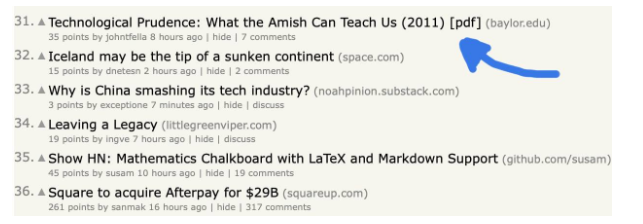

Функция get_load_time() будет считаться для каждой новостной страницы из списка.

→ write_to_file()

Этот метод нужен для сохранения результатов в файл. Подробнее про библиотеку csv и её инструменты можно почитать в документации. https://docs.python.org/3/library/csv.html

In [11]:
def write_to_file(output_list, filename, base_dir):
    for row in output_list:
        with open(Path(base_dir).joinpath(filename), "a") as csvfile:
            fieldnames = ["id", "load_time", "rank", "points", "title", "url"]
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writerow(row)

→ connect_to_base()

Прежде чем брать данные с открытой в Selenium страницы, необходимо некоторое время для загрузки на страницу контента. Этот метод ожидает загрузку таблицы на страницу некоторое время и возвращает TRUE в случае её доступности.

WebDriverWait говорит Selenium ждать, пока не выполнится некоторое условие (пока таблица не подгрузится). Подробнее прочитать про режимы ожидания можно в документации. 

In [12]:
def connect_to_base(browser, page_number):
    base_url = "https://news.ycombinator.com/news?p={}".format(page_number)
    for connection_attempts in range(1,4): # совершаем 3 попытки подключения
        try:
            browser.get(base_url)
            # ожидаем пока элемент table с id = 'hnmain' будет загружен на страницу
            # затем функция вернет True иначе False 
            WebDriverWait(browser, 5).until(
                EC.presence_of_element_located((By.ID, "hnmain"))
            )
            return True
        except Exception as e:
            print(e)
            print("Error connecting to {}.".format(base_url))
            print("Attempt #{}.".format(connection_attempts))
    return False

→ parse_html()

А в этой функции мы будем парсить страницу с Beautiful Soup, извлекая необходимые атрибуты и записывая их в список.

In [13]:
def parse_html(html, user_agent):
    soup = BeautifulSoup(html, "html.parser")
    output_list = []
   
    # ищем в объекте soup object id, rank, score и title статьи
    tr_blocks = soup.find_all("tr", class_="athing")
    article = 0
    for tr in tr_blocks:
        article_id = tr.get("id") # id
        article_url = tr.find_all("a")[1]["href"]

        # иногда статья располагается не на внешнем сайте, а на ycombinator
        # тогда article_url у нее не полный, а добавочный, с параметрами.
        # например item?id=200933. Для этих случаев будем добавлять url до полного
        if "item?id=" in article_url or "from?site=" in article_url:
            article_url = f"https://news.ycombinator.com/{article_url}"
        load_time = get_load_time(article_url, user_agent)
        # иногда рейтинга может не быть, поэтому воспользуемся try

        try:
            score = soup.find(id=f"score_{article_id}").string
        except Exception as e:
            print(e)
            score = "0 points"
           
        article_info = {
            "id": article_id,
            "load_time": load_time,
            "rank": tr.span.string,
            "points": score,
            "title": tr.find(class_="titleline").string,
            "url": article_url,
        }

        # добавляем информацию о статье в список
        output_list.append(article_info)
        article += 1
    return output_list

⭐️ Вспомогательные методы готовы! Напишем основной код для запуска:

In [14]:
start_time = time() # время начала выполнения программы

# инициализируем веб драйвер
browser = webdriver.Chrome(
    service=ChromeService(executable_path=driver_path)
)

# перебираем страницы и собираем нужную информацию
for page_number in range(10):
    print("getting page " + str(page_number) + "...")
    if connect_to_base(browser, page_number):
        sleep(5)
        output_list = parse_html(browser.page_source, user_agent)
        write_to_file(output_list, filename, base_dir)

    else:
        print("Error connecting to hacker news")

# завершаем работу драйвера
browser.close()
sleep(1)
browser.quit()
end_time = time()
elapsed_time = end_time - start_time
print("run time: {} seconds".format(elapsed_time))

getting page 0...
HTTPSConnectionPool(host='www.dabeaz.com', port=443): Max retries exceeded with url: /courses.html (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)')))
'NoneType' object has no attribute 'string'
getting page 1...
HTTPSConnectionPool(host='www.dabeaz.com', port=443): Max retries exceeded with url: /courses.html (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)')))
'NoneType' object has no attribute 'string'
getting page 2...
getting page 3...
getting page 4...
HTTPSConnectionPool(host='www.washingtonpost.com', port=443): Read timed out. (read timeout=3.0)
getting page 5...
getting page 6...
HTTPConnectionPool(host='58.84.62.202', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='58.84.62.202', port=80) a

Чтобы подражать человеку-пользователю, вызывается метод sleep(5), который вносит задержку на 5 секунд после того, как драйвер подключился к Hacker News. После загрузки страницы и выполнения sleep(5) драйвер захватывает HTML-код страницы, который затем передаётся в функцию parse_html().

В результате выполнения кода будет создан файл articles_info.csv, который будет содержать всю информацию, которую мы спарсили. Мы можем прочитать этот файл и представить таблицу в виде DataFrame:

In [15]:
import pandas as pd

articles_data = pd.read_csv(
    './parse/articles_info.csv',
    names=["id", "load_time", "rank", "points", "title", "url"],
    encoding='cp1252'
)

articles_data.head()

,id,load_time,rank,points,title,url
0,48783117,0.170701,1.0,28 points,NaN,https://blog.mikebowler.ca/2026/07/03/co2-and-...
1,48782671,0.392772,2.0,59 points,NaN,https://danluu.com/ai-coding/#appendix-agentic...
2,48782890,0.607733,3.0,11 points,NaN,https://www.hyperstitionai.com/unslop-results
3,48780417,0.112117,4.0,211 points,NaN,https://www.wafer.ai/blog/glm52-amd
4,48780801,0.182098,5.0,187 points,NaN,https://mistral.ai/news/leanstral-1-5/


### ✏️Попробуйте сами!

Запустите код в Jupyter Notebook или другой удобной для вас среде. Время выполнения кода — примерно минута. 

Попробуйте изменить различные параметры и посмотреть на результат. 

Обратите внимание: при запуске кода открывается браузер и в строке запросов будет меняться значение p (p=0, p=1...p=10). Так Selenium переключает страницы.

Задание. Добавьте к атрибутам количество комментариев по новости.

### Многопоточность 

Начинается веселье!

Запустим многопоточность, немного изменив наш основной код — вынесем его в отдельную функцию и будем запускать её в потоке:

In [16]:
from concurrent.futures import ThreadPoolExecutor, wait

# Обернём процедуру парсинга страницы в функцию
def run_process(page_number, filename):
    browser = webdriver.Chrome(
        service=ChromeService(executable_path=driver_path)
    )
    if connect_to_base(browser, page_number):
        sleep(5)
        output_list = parse_html(browser.page_source, user_agent)
        write_to_file(output_list, filename, base_dir)
       
        browser.quit()
    else:
        print("Error connecting to hacker news")
        browser.quit()
       
# Глобальные переменные        
filename = "articles_info_new.csv" # имя файла, в который будем сохранять результат
driver_path = "./chromedriver-win64/chromedriver.exe" # укажите ваш путь к chromedriver, который вы загрузили ранее
base_dir= "./parse/" # укажите директорию, в которую будем сохранять файл
user_agent = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/92.0.4515.107 Safari/537.36"

# Засечём время выполнения кода
start_time = time()

futures = []

# Запустим процесс парсинга на нескольких потоках одновременно
with ThreadPoolExecutor() as executor:
    for number in range(10):
        futures.append(
            executor.submit(run_process, number, filename)
        )
       
wait(futures)
end_time = time()
elapsed_time = end_time - start_time
print("Elapsed run time: {} seconds".format(elapsed_time))

HTTPSConnectionPool(host='github.com', port=443): Max retries exceeded with url: /anuragmerndev/kontext-ai (Caused by ConnectTimeoutError(<HTTPSConnection(host='github.com', port=443) at 0x15d6a75f790>, 'Connection to github.com timed out. (connect timeout=3.0)'))
HTTPSConnectionPool(host='www.dabeaz.com', port=443): Max retries exceeded with url: /courses.html (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)')))
HTTPSConnectionPool(host='www.dabeaz.com', port=443): Max retries exceeded with url: /courses.html (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)')))
HTTPSConnectionPool(host='blog.archive.org', port=443): Read timed out. (read timeout=3.0)
HTTPSConnectionPool(host='blog.archive.org', port=443): Read timed out. (read timeout=3.0)
HTTPSConnectionPool(host=

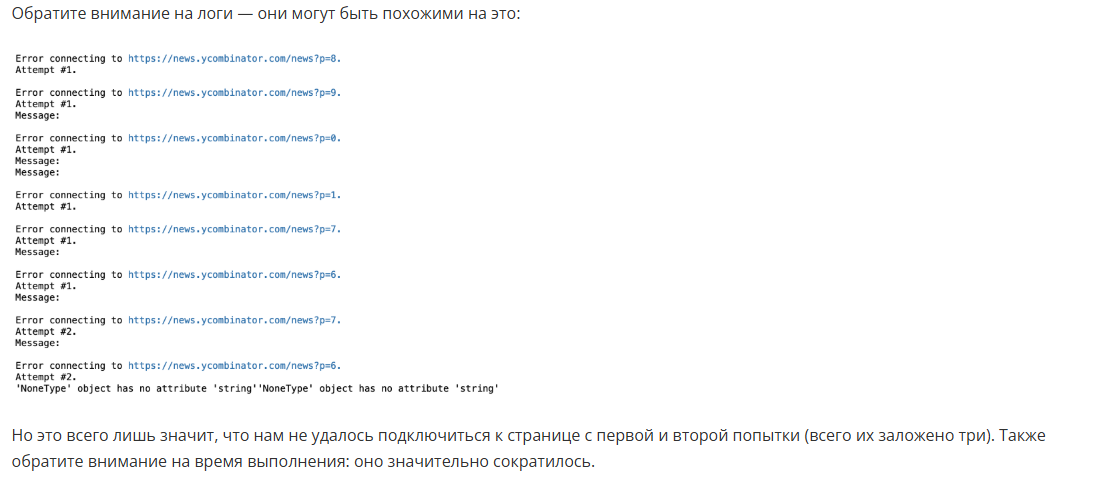

## Задание 12.1. Практика 2 (HW-03)
